In [3]:
# Load Libraries
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# Cargamos el dataset
df = pd.read_csv('smart_logistics_dataset.csv')
display(df.describe())

,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-1.360093,0.837049,297.915000,23.893900,65.042200,35.062000,299.055000,5.513000,79.599100,199.284000,0.566000
std,51.997183,104.843618,113.554773,3.322178,8.753765,14.477768,117.787792,2.935379,11.631153,59.920847,0.495873
min,-89.791500,-179.820200,100.000000,18.000000,50.000000,10.000000,100.000000,1.000000,60.000000,100.000000,0.000000
25%,-46.167975,-88.448075,201.000000,21.200000,57.200000,23.000000,191.750000,3.000000,69.475000,144.000000,0.000000
50%,-4.503150,0.678300,299.000000,23.800000,65.200000,35.000000,301.500000,6.000000,79.250000,202.000000,1.000000
75%,44.502800,88.156450,399.000000,26.600000,72.400000,49.000000,405.000000,8.000000,89.425000,251.250000,1.000000
max,89.870100,179.923700,500.000000,30.000000,80.000000,60.000000,500.000000,10.000000,100.000000,300.000000,1.000000


Gráfico de relación


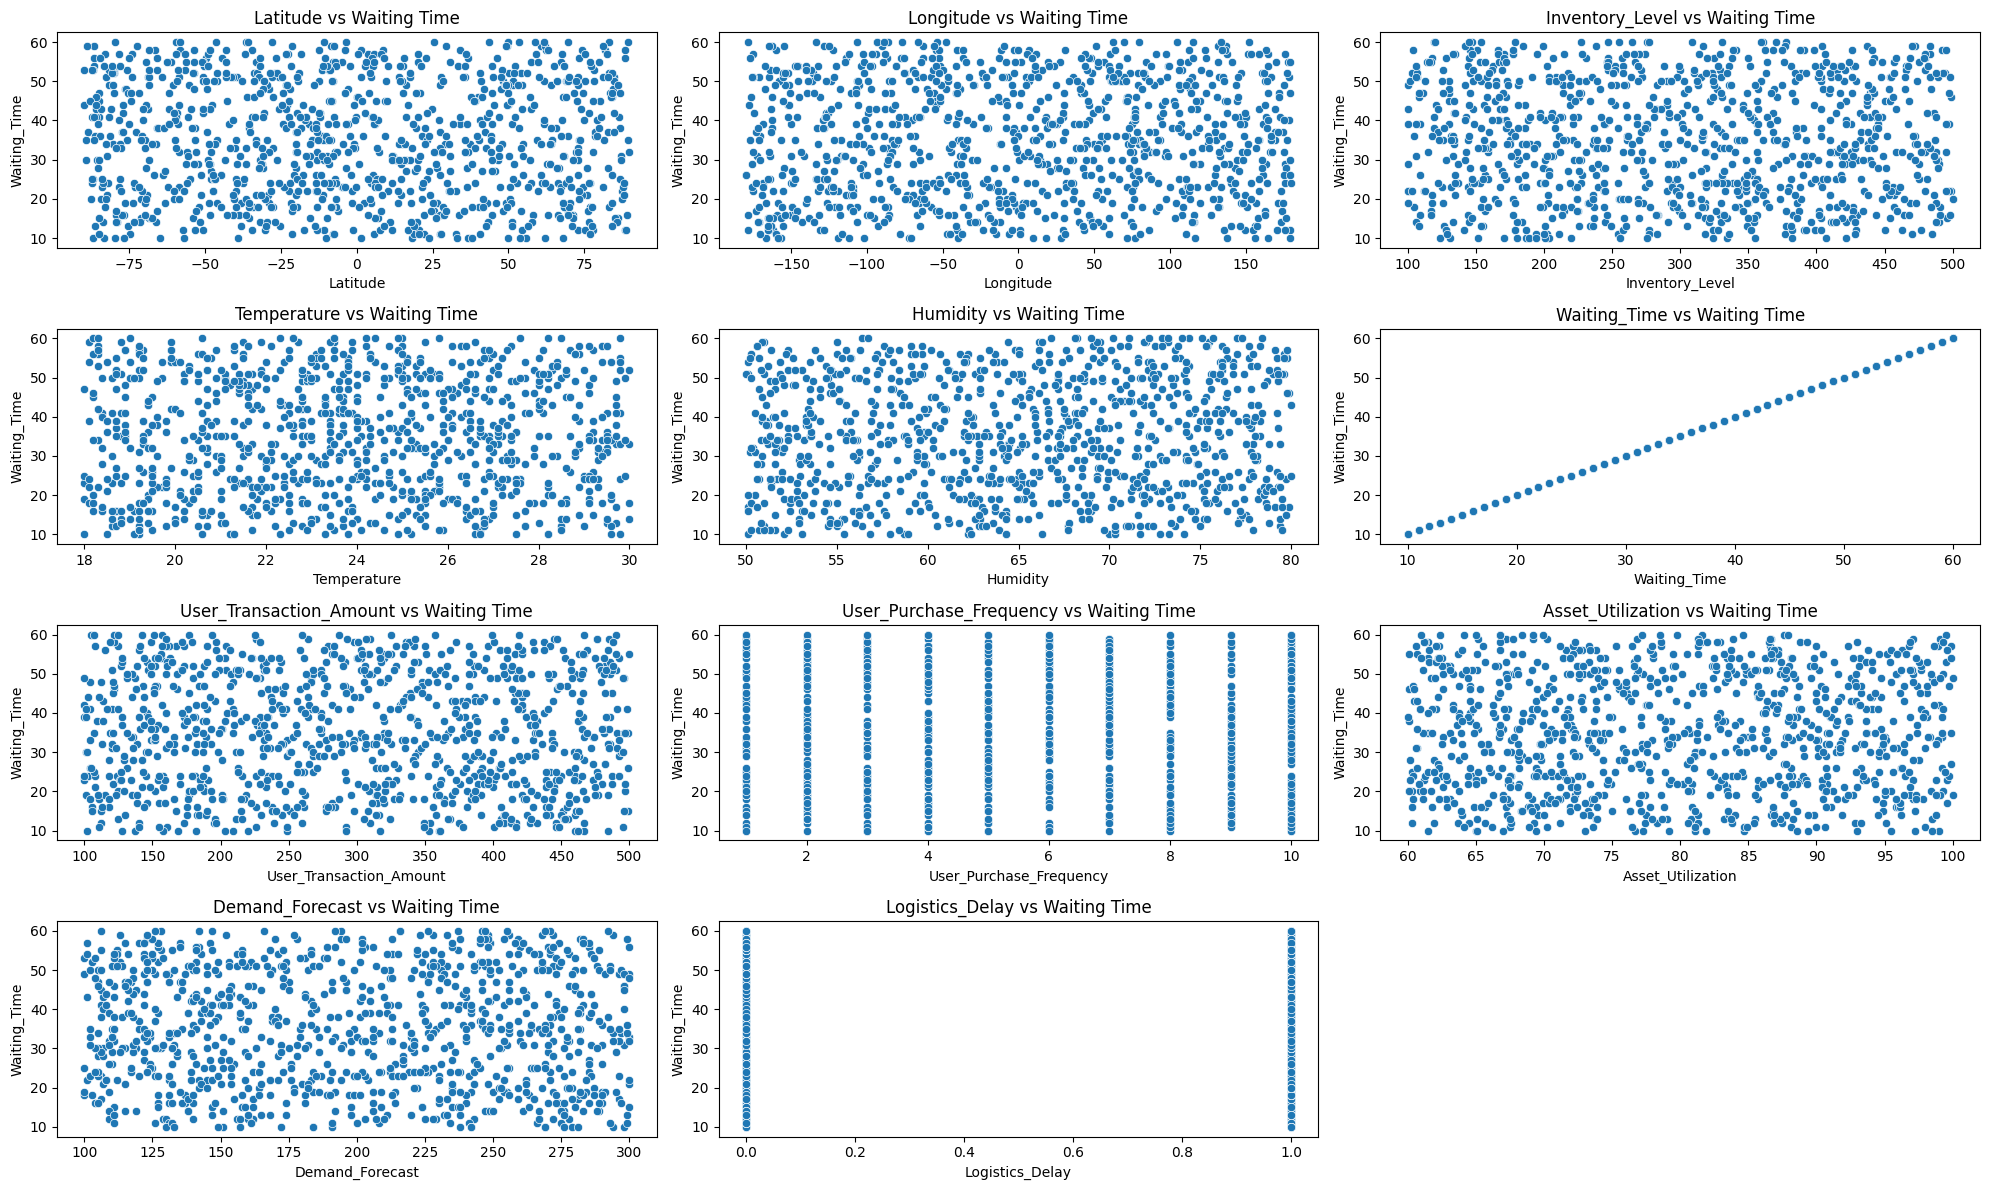

In [5]:
# Gráfico de relación
print("Gráfico de relación")
t = 'Waiting Time'
fts = [col for col in df.columns if col != t]
plt.figure(figsize=(20, 12))
for i, feature in enumerate(fts):
    plt.subplot(4, 3, i+1)
    sns.scatterplot(data=df, x=feature, y=df.columns[5])
    plt.title(f'{feature} vs {t}')
plt.tight_layout()
plt.show()

Mapa de calor


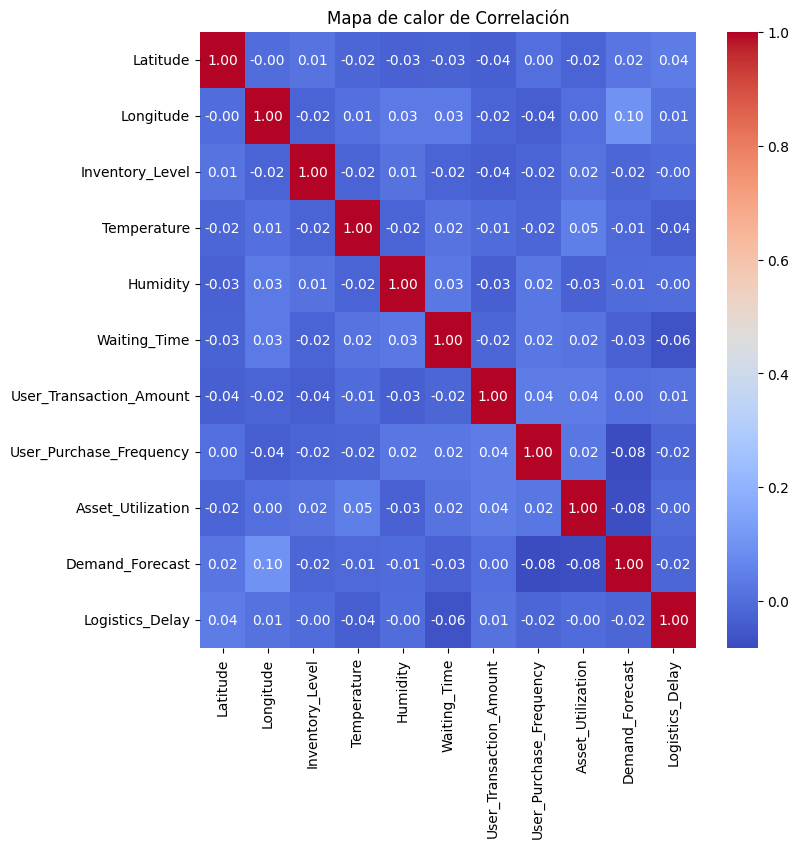

In [6]:
# mapa de calor de correlación
print("Mapa de calor")
plt.figure(figsize=(8, 8))
cor_m = df.corr()
sns.heatmap(cor_m, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de Correlación')
plt.show()

Comenzaremos con entrenar 2 modelos con todas las columnas excepto la columna de la variable objetivo

In [7]:
def plot_real_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    lims = [min(np.min(y_true), np.min(y_pred)), max(np.max(y_true), np.max(y_pred))]
    plt.plot(lims, lims)  # y = x
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("Real")
    plt.ylabel("Predicho")
    plt.title(title)
    plt.tight_layout()
    plt.show()

Linear Regression → MSE: 217.11, R²: -0.01, RMSE: 14.734617925376863
Polynomial Regression (deg 2) → MSE: 238.79, R²: -0.11, RMSE: 15.452917271396663


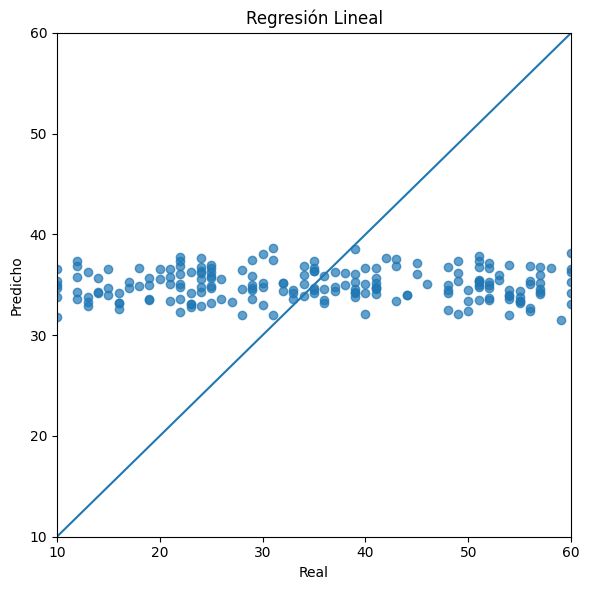

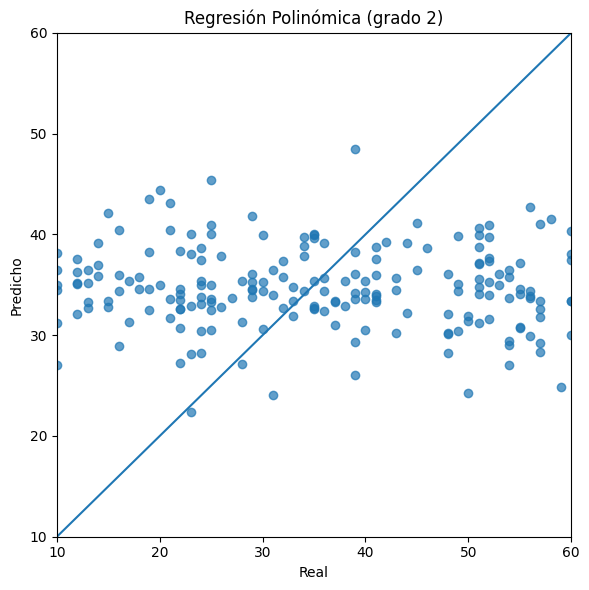

In [8]:
# separar variables, quitamos Waiting_Time porque es el target y son 10 variables en total
X = df.drop("Waiting_Time", axis=1)
y = df["Waiting_Time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1: regresión lineal
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
print(f"Linear Regression → MSE: {mse_linear:.2f}, R²: {r2_linear:.2f}, RMSE: {mse_linear**0.5}")

# 2: regresión no lineal (polinómico grado 2)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Polynomial Regression (deg 2) → MSE: {mse_poly:.2f}, R²: {r2_poly:.2f}, RMSE: {mse_poly**0.5}")

# Gráficas
plot_real_vs_pred(y_test, y_pred_linear, "Regresión Lineal")
plot_real_vs_pred(y_test, y_pred_poly, "Regresión Polinómica (grado 2)")

Continuaremos con entrenar un modelo lineal y otro no lineal, basándonos solo en las 3 variables con mayor correlación

In [9]:
# Modelo Lineal 2 variables: Longitude + Humidity
X1 = df[['Longitude',
         'Humidity']]

# Dividir en entrenamiento y prueba (80%-20%)
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

# Crear y entrenar modelo
model1 = LinearRegression()
model1.fit(X1_train, y_train)

# Predecir y evaluar
y1_pred = model1.predict(X1_test)
print("=== Modelo 1: Longitude + Humidity ===")
print("Coeficientes:", model1.coef_)
print("Intercept:", model1.intercept_)
print("R^2:", r2_score(y_test, y1_pred))
print("RMSE:", mean_squared_error(y_test, y1_pred))
print("\n")


# Modelo no lineal 2 variables: Longitude + Humidity

# Crear pipeline de regresión polinomial grado 2
poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())

# Entrenar modelo
poly_model.fit(X1_train, y_train)

# Predicción
y_pred_nl = poly_model.predict(X1_test)

# Métricas
r2_nl = r2_score(y_test, y_pred_nl)
rmse_nl = np.sqrt(mean_squared_error(y_test, y_pred_nl))

=== Modelo 1: Longitude + Humidity ===
Coeficientes: [0.00559097 0.07396426]
Intercept: 30.17359242018548
R^2: -0.007847431936779614
RMSE: 216.7597376853213




In [10]:
# Calcular métricas
r2_model1 = r2_score(y_test, y1_pred)
rmse_model1 = np.sqrt(mean_squared_error(y_test, y1_pred))

# Crear tabla comparativa
results = pd.DataFrame({
    "Modelo": ["Linear Regression (All variables)", "Polynomial Regression  (All variables, deg 2)", "Modelo lineal (2 variables): Longitude + Humidity","Polinomial (2 variables) (Longitude + Humidity, grado 2"],
    "R²": [r2_linear, r2_poly, r2_model1, r2_nl],
    "RMSE": [np.sqrt(mse_linear), np.sqrt(mse_poly), rmse_model1,rmse_nl]
})

display(results)

,Modelo,R²,RMSE
0,Linear Regression (All variables),-0.009471,14.734618
1,"Polynomial Regression (All variables, deg 2)",-0.110292,15.452917
2,Modelo lineal (2 variables): Longitude + Humidity,-0.007847,14.722763
3,Polinomial (2 variables) (Longitude + Humidity...,-0.018140,14.797749


Optimize Hyperparameters

Polynomial Regression (deg 3) → MSE: 384.49, R²: -0.79, RMSE: 19.608361294941204


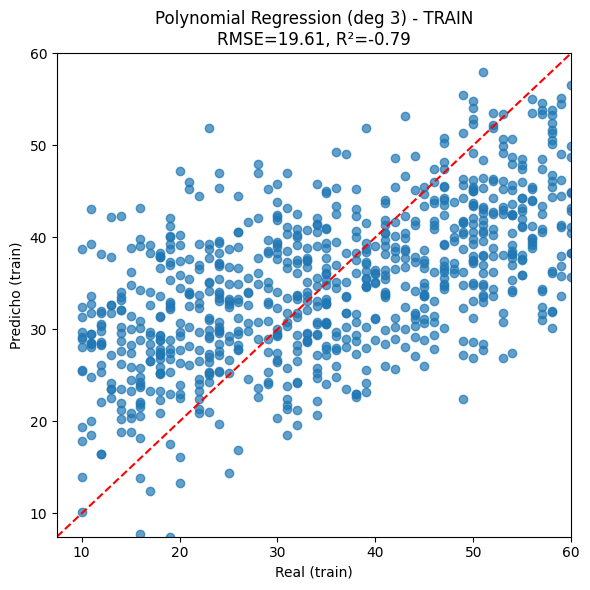

Polynomial Regression (deg 4) → MSE: 20613.23, R²: -94.84, RMSE: 143.5730735857127
Polynomial Regression (deg 5) → MSE: 7555.44, R²: -34.13, RMSE: 86.92201622161028


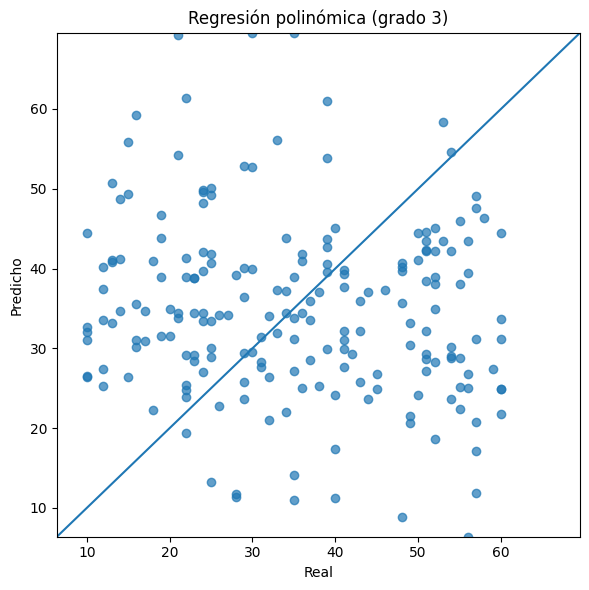

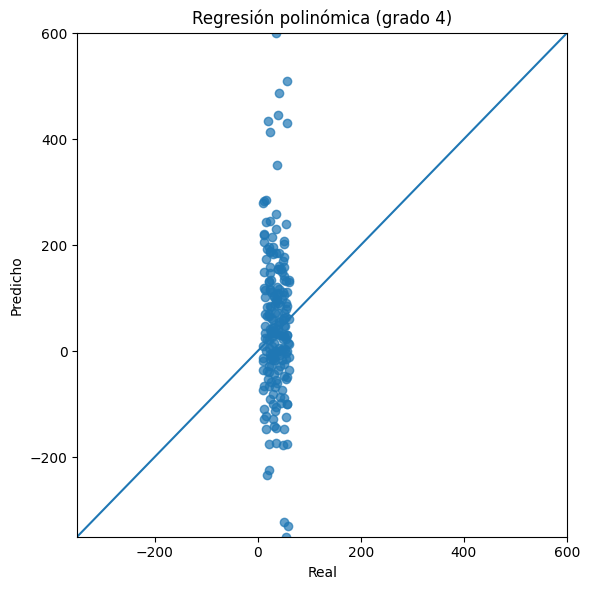

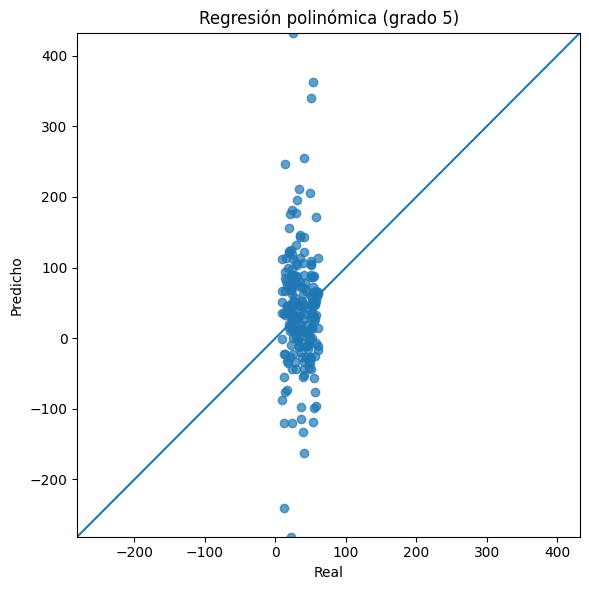

In [11]:
X = df.drop("Waiting_Time", axis=1)
y = df["Waiting_Time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# modelo alternativo (regresión polinómica grado 3)
poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_model.fit(X_train, y_train)
y_pred_poly_prueba1 = poly_model.predict(X_test)
mse_poly_prueba1 = mean_squared_error(y_test, y_pred_poly_prueba1)
r2_poly_prueba1 = r2_score(y_test, y_pred_poly_prueba1)
print(f"Polynomial Regression (deg 3) → MSE: {mse_poly_prueba1:.2f}, R²: {r2_poly_prueba1:.2f}, RMSE: {mse_poly_prueba1**0.5}")


y_pred_train = poly_model.predict(X_train)
# ---- Modelo ganador: polinómico grado 3 (reentrena por claridad) ----
best_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
best_model.fit(X_train, y_train)


plt.figure(figsize=(6,6))
plt.scatter(y_train, y_pred_train, alpha=0.7)
lims = [min(np.min(y_train), np.min(y_pred_train)),
        max(np.max(y_train), np.max(y_pred_train))]
plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Real (train)")
plt.ylabel("Predicho (train)")
plt.title(f"Polynomial Regression (deg 3) - TRAIN\nRMSE={mse_poly_prueba1**0.5:.2f}, R²={r2_poly_prueba1:.2f}")
plt.tight_layout()
plt.show()


# modelo alternativo (regresión polinómica grado 4)
poly_model = make_pipeline(PolynomialFeatures(degree=4), LinearRegression())
poly_model.fit(X_train, y_train)
y_pred_poly_prueba2 = poly_model.predict(X_test)
mse_poly_prueba2 = mean_squared_error(y_test, y_pred_poly_prueba2)
r2_poly_prueba2 = r2_score(y_test, y_pred_poly_prueba2)
print(f"Polynomial Regression (deg 4) → MSE: {mse_poly_prueba2:.2f}, R²: {r2_poly_prueba2:.2f}, RMSE: {mse_poly_prueba2**0.5}")

# modelo alternativo (regresión polinómica grado 5)
poly_model = make_pipeline(PolynomialFeatures(degree=5), LinearRegression())
poly_model.fit(X_train, y_train)
y_pred_poly_prueba3 = poly_model.predict(X_test)
mse_poly_prueba3 = mean_squared_error(y_test, y_pred_poly_prueba3)
r2_poly_prueba3 = r2_score(y_test, y_pred_poly_prueba3)
print(f"Polynomial Regression (deg 5) → MSE: {mse_poly_prueba3:.2f}, R²: {r2_poly_prueba3:.2f}, RMSE: {mse_poly_prueba3**0.5}")

# GRAFICAS

# Grado 3
plot_real_vs_pred(y_test, y_pred_poly_prueba1, "Regresión polinómica (grado 3)")

# Grado 4
plot_real_vs_pred(y_test, y_pred_poly_prueba2, "Regresión polinómica (grado 4)")

# Grado 5
plot_real_vs_pred(y_test, y_pred_poly_prueba3, "Regresión polinómica (grado 5)")

In [12]:
model1.coef_

array([0.00559097, 0.07396426])

In [13]:
import joblib # imita el comportaminto de ejecutar comandos en terminal
joblib.dump(model1, 'linear_regression_model.pkl')
print("Model saved as 'linear_regression_model.pkl'")

Model saved as 'linear_regression_model.pkl'
